# 🏠 Handling Missing Values
### Kenya Real Estate Listings Dataset

---

This notebook is a ** guide** to handling missing data — from initial diagnosis through to a fully imputed dataset.

| Phase | What we do |
|---|---|
| **1. Diagnosis** | Quantify, visualise, and classify missing data |
| **2. Mechanism Analysis** | Determine *why* data is missing (MCAR / MAR / MNAR) |
| **3. Structural Cleaning** | Drop high-missingness columns & multi-missing rows |
| **4. Domain Imputation** | Fill using business rules (Studio / Bedsitter → Bedrooms = 1) |
| **5. Statistical Imputation** | Median / mode fills for simple cases |
| **6. Model-Based Imputation** | MICE + Random Forest for complex cases |
| **7. Validation** | Verify distributions are preserved, zero nulls remain |

---

## ⚙️ 0 — Setup: Imports & Configuration

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Core libraries
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd                   # DataFrame operations
import numpy as np                    # Numerical computing
import warnings
warnings.filterwarnings('ignore')     # Suppress convergence / deprecation noise

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# ─────────────────────────────────────────────────────────────────────────────
# Scikit-learn: imputation & modelling
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.preprocessing   import LabelEncoder
from sklearn.experimental    import enable_iterative_imputer   # activate MICE imputer
from sklearn.impute          import IterativeImputer, SimpleImputer
from sklearn.ensemble        import RandomForestRegressor
from sklearn.linear_model    import BayesianRidge               # lightweight alternative estimator

# ─────────────────────────────────────────────────────────────────────────────
# Styling
# ─────────────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (13, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ─────────────────────────────────────────────────────────────────────────────
# Colour palette used throughout
# ─────────────────────────────────────────────────────────────────────────────
C = dict(
    drop    = '#e74c3c',   # red   — dropped / high-miss
    warn    = '#f39c12',   # amber — moderate miss
    ok      = '#27ae60',   # green — low miss / imputed
    blue    = '#2980b9',   # blue  — general
    purple  = '#8e44ad',   # purple
    before  = '#e74c3c',
    after   = '#27ae60',
)

print('✅  All libraries loaded.')

✅  All libraries loaded.


---
## 📂 1 — Load & First Look

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Load the raw CSV.
# encoding='utf-8-sig' strips the byte-order mark (BOM) written by Excel/Windows.
# ─────────────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('raw_listings.csv', encoding='utf-8-sig')

# Work on a copy so we can always compare against the original
df = df_raw.copy()

print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head(8)

Rows: 926   Columns: 8


,Location,Property Type,Bedrooms,Bathrooms,Size (m2),Amenities,Price (KES),Listing Date
0,Westlands,Land,1.0,2.0,65.0,Swimming Pool,5500000.0,NaN
1,Westlands,Villa,6.0,6.0,NaN,En Suite,260000000.0,NaN
2,Kileleshwa,Apartment,1.0,2.0,65.0,Swimming Pool,6000000.0,NaN
3,Kileleshwa,Apartment,1.0,1.0,47.0,Swimming Pool,5100000.0,NaN
4,Westlands,Land,NaN,NaN,NaN,NaN,25000000.0,NaN
5,Lavington,Townhouse,5.0,6.0,NaN,En Suite,75000000.0,NaN
6,Lavington,Townhouse,5.0,6.0,NaN,En Suite,81000000.0,NaN
7,Lavington,Townhouse,6.0,7.0,NaN,En Suite,85000000.0,NaN


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Schema overview — column names, non-null counts, dtypes
# ─────────────────────────────────────────────────────────────────────────────
df.info()

print('\n── Numeric summary ──')
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 926 entries, 0 to 925
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       926 non-null    object 
 1   Property Type  926 non-null    object 
 2   Bedrooms       792 non-null    float64
 3   Bathrooms      463 non-null    float64
 4   Size (m2)      466 non-null    float64
 5   Amenities      696 non-null    object 
 6   Price (KES)    698 non-null    float64
 7   Listing Date   14 non-null     float64
dtypes: float64(5), object(3)
memory usage: 58.0+ KB

── Numeric summary ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Location,926,58,Westlands,159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Property Type,926,10,Apartment,376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bedrooms,792.0,NaN,NaN,NaN,3.042929,2.853467,1.0,2.0,3.0,4.0,54.0
Bathrooms,463.0,NaN,NaN,NaN,3.062635,2.760726,1.0,2.0,3.0,4.0,44.0
Size (m2),466.0,NaN,NaN,NaN,1385.979828,5179.298461,8.0,70.0,166.5,500.0,80937.0
Amenities,696,191,SQ,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (KES),698.0,NaN,NaN,NaN,56210929.861032,182676302.28412,65.0,9000000.0,15000000.0,43750000.0,2026000000.0
Listing Date,14.0,NaN,NaN,NaN,10.642857,3.177012,8.0,8.25,10.0,11.0,19.0


---
## 🔬 2 — Phase 1: Missing Value Diagnosis

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Build a comprehensive missing-value audit table
# ─────────────────────────────────────────────────────────────────────────────
def missing_audit(dataframe):
    """Return a DataFrame summarising missingness per column."""
    total   = len(dataframe)
    counts  = dataframe.isnull().sum()                      # raw count of NaN per column
    pct     = (counts / total * 100).round(2)               # as a percentage
    present = total - counts                                 # non-missing count

    # Classify severity so analysts can quickly triage
    def severity(p):
        if p == 0:    return '✅  None'
        if p < 5:     return '🟢 Low  (<5%)'
        if p < 20:    return '🟡 Moderate (5–20%)'
        if p < 55:    return '🟠 High (20–55%)'
        return            '🔴 Critical (>55%) — consider dropping'

    audit = pd.DataFrame({
        'Non-Missing'  : present,
        'Missing Count': counts,
        'Missing %'    : pct,
        'Dtype'        : dataframe.dtypes.astype(str),
        'Severity'     : pct.map(severity)
    }).sort_values('Missing %', ascending=False)

    return audit

audit = missing_audit(df)
print('=== Missing Value Audit ===')
audit

=== Missing Value Audit ===


,Non-Missing,Missing Count,Missing %,Dtype,Severity
Listing Date,14,912,98.49,float64,🔴 Critical (>55%) — consider dropping
Bathrooms,463,463,50.00,float64,🟠 High (20–55%)
Size (m2),466,460,49.68,float64,🟠 High (20–55%)
Amenities,696,230,24.84,object,🟠 High (20–55%)
Price (KES),698,228,24.62,float64,🟠 High (20–55%)
Bedrooms,792,134,14.47,float64,🟡 Moderate (5–20%)
Location,926,0,0.00,object,✅ None
Property Type,926,0,0.00,object,✅ None


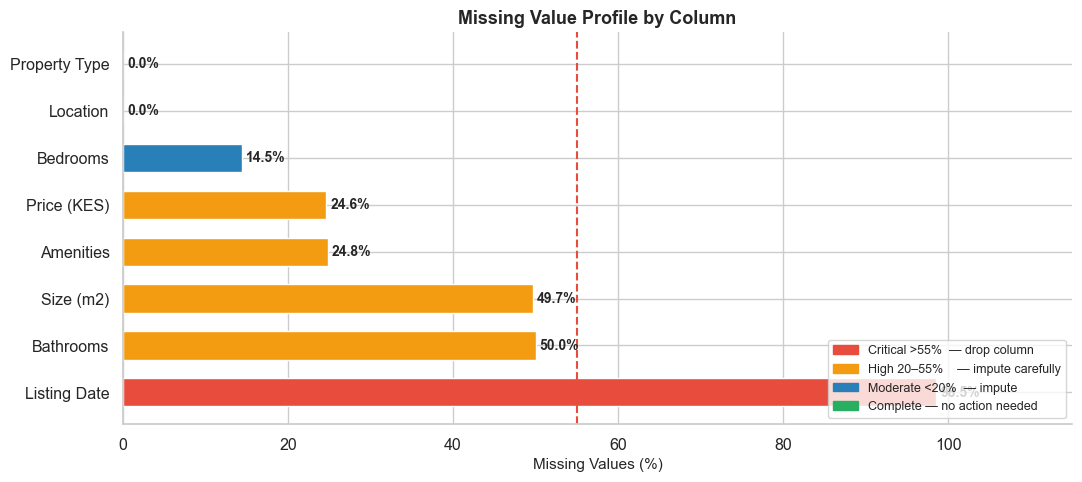

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION 1: Horizontal bar chart — missing % per column
# Bars are colour-coded by severity; a threshold line marks the 55% drop zone.
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

# Assign colour to each bar based on missingness %
bar_colors = [
    C['drop']   if v > 55
    else C['warn'] if v > 20
    else C['blue'] if v > 0
    else C['ok']
    for v in audit['Missing %']
]

bars = ax.barh(audit.index, audit['Missing %'], color=bar_colors, edgecolor='white', height=0.6)

# Annotate each bar with its exact percentage
for bar, val in zip(bars, audit['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

# 55% threshold reference line
ax.axvline(55, color=C['drop'], linestyle='--', linewidth=1.5, label='55% drop threshold')

# Legend patches for colour key
legend_patches = [
    mpatches.Patch(color=C['drop'],  label='Critical >55%  — drop column'),
    mpatches.Patch(color=C['warn'],  label='High 20–55%    — impute carefully'),
    mpatches.Patch(color=C['blue'],  label='Moderate <20%  — impute'),
    mpatches.Patch(color=C['ok'],    label='Complete — no action needed'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax.set_xlabel('Missing Values (%)', fontsize=11)
ax.set_title('Missing Value Profile by Column', fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

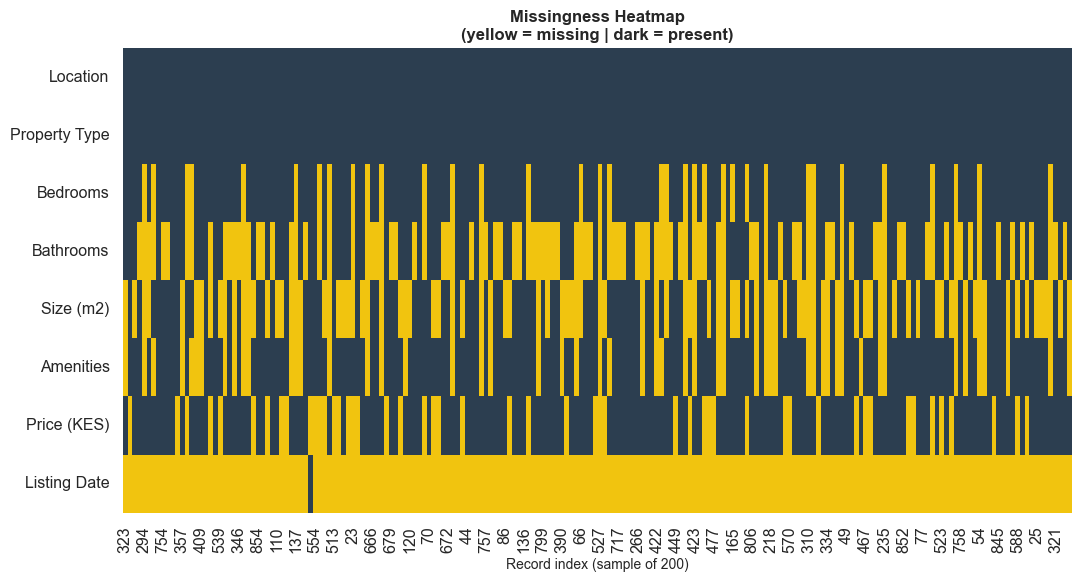


📌 What to look for:
  • Vertical streaks spanning multiple columns → records are missing ALL values (likely junk rows)
  • Horizontal streaks in one column only     → systematic column-level issue
  • Random scatter                             → Missing Completely At Random (MCAR)



In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION 2: Missingness Heatmap
# Each row = one record; yellow = missing, purple = present.
# Patterns (vertical streaks) reveal whether columns go missing together.
# We sample 200 rows for clarity.
# ─────────────────────────────────────────────────────────────────────────────
sample = df.sample(200, random_state=42)          # random sample to keep the plot readable
miss_matrix = sample.isnull().astype(int)         # 1 where data is missing, 0 otherwise

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    miss_matrix.T,                                # transpose so columns are rows in the heatmap
    cmap=['#2c3e50', '#f1c40f'],                  # dark = present, yellow = missing
    cbar=False,
    linewidths=0,
    ax=ax
)
ax.set_xlabel('Record index (sample of 200)', fontsize=10)
ax.set_ylabel('')
ax.set_title('Missingness Heatmap\n(yellow = missing | dark = present)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
📌 What to look for:
  • Vertical streaks spanning multiple columns → records are missing ALL values (likely junk rows)
  • Horizontal streaks in one column only     → systematic column-level issue
  • Random scatter                             → Missing Completely At Random (MCAR)
""")

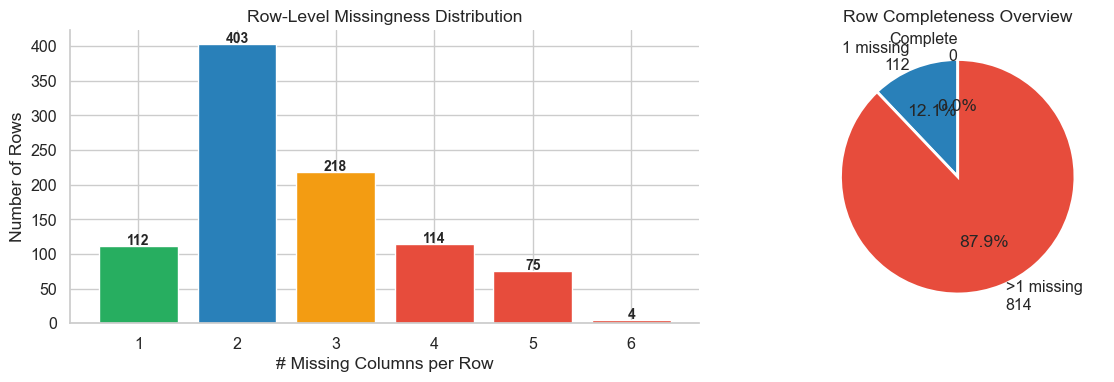

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION 3: Per-row missingness distribution
# How many columns are simultaneously missing for each row?
# ─────────────────────────────────────────────────────────────────────────────
row_miss = df.isnull().sum(axis=1)                # count of missing values per row
row_dist = row_miss.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: bar chart
axes[0].bar(row_dist.index, row_dist.values,
            color=[C['ok'], C['blue'], C['warn'], C['drop'], C['drop'], C['drop'], C['drop']],
            edgecolor='white')
for i, v in zip(row_dist.index, row_dist.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('# Missing Columns per Row')
axes[0].set_ylabel('Number of Rows')
axes[0].set_title('Row-Level Missingness Distribution')

# Right: pie chart showing proportion completeness vs incomplete
complete   = (row_miss == 0).sum()              # rows with zero missing values
one_miss   = (row_miss == 1).sum()              # rows with exactly 1 missing
multi_miss = (row_miss > 1).sum()               # rows missing >1 value

axes[1].pie(
    [complete, one_miss, multi_miss],
    labels=[f'Complete\n{complete}', f'1 missing\n{one_miss}', f'>1 missing\n{multi_miss}'],
    colors=[C['ok'], C['blue'], C['drop']],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Row Completeness Overview')

plt.tight_layout()
plt.show()

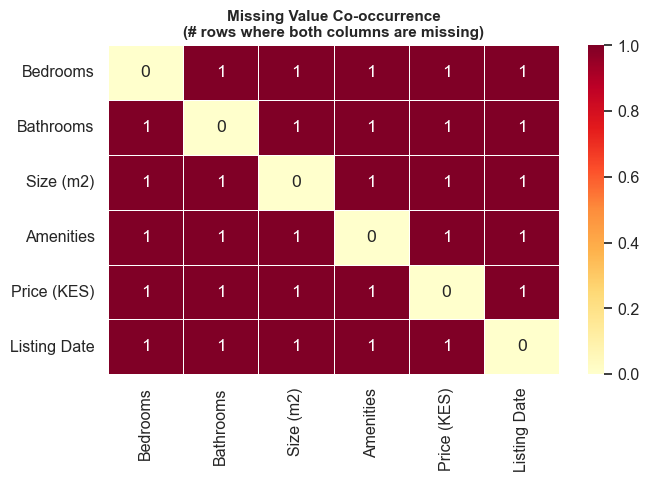


📌 Interpretation:
  High values → those columns frequently go missing together
  This often indicates MNAR (Missing Not At Random) — the missingness
  is linked to a latent factor, e.g. agents submitting incomplete listing forms.



In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION 4: Co-occurrence matrix
# Which pairs of columns tend to be missing in the same row?
# A high co-occurrence suggests a structural / MNAR issue.
# ─────────────────────────────────────────────────────────────────────────────
miss_bool   = df.isnull()                         # True/False per cell
co_occur    = miss_bool.T.dot(miss_bool)          # dot product: (col × row) · (row × col) = col × col count
np.fill_diagonal(co_occur.values, 0)              # zero out self-co-occurrence (diagonal)

# Only show columns that have at least 1 missing value
miss_cols = [c for c in df.columns if df[c].isnull().any()]
co_sub = co_occur.loc[miss_cols, miss_cols]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    co_sub,
    annot=True, fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Missing Value Co-occurrence\n(# rows where both columns are missing)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
📌 Interpretation:
  High values → those columns frequently go missing together
  This often indicates MNAR (Missing Not At Random) — the missingness
  is linked to a latent factor, e.g. agents submitting incomplete listing forms.
""")

---
## 🧠 3 — Phase 2: Missingness Mechanism Analysis

Understanding *why* data is missing determines *how* to handle it:

| Mechanism | What it means | Best strategy |
|---|---|---|
| **MCAR** — Missing Completely At Random | Missingness has no pattern; equally likely for any row | Any imputation method works |
| **MAR** — Missing At Random | Missingness is related to *other observed* variables | Model-based or conditional imputation |
| **MNAR** — Missing Not At Random | Missingness depends on the *missing value itself* | Requires domain logic; flag as a feature |

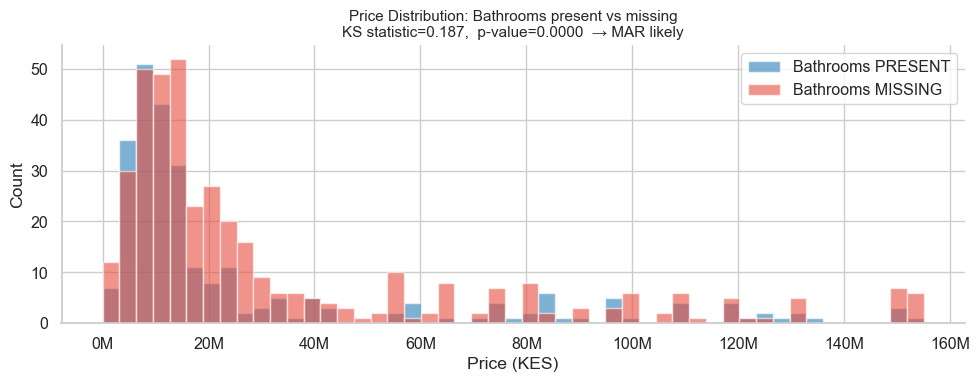


📊 KS Test result:
   Statistic : 0.1874
   p-value   : 0.0000

⚠️  p < 0.05 → Price distribution DIFFERS between missing/present Bathrooms rows.



In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Test for MAR: do numeric distributions differ between rows where
# Bathrooms is missing vs present?
# If they differ significantly → Bathrooms is MAR (at least w.r.t. Price)
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import ks_2samp              # Kolmogorov-Smirnov test for distributional difference

target_col  = 'Bathrooms'                     # column we're testing
compare_col = 'Price (KES)'                   # numeric column to compare distribution

# Split rows into those where Bathrooms is missing vs present
miss_mask    = df[target_col].isnull()
price_when_missing  = df.loc[ miss_mask, compare_col].dropna()
price_when_present  = df.loc[~miss_mask, compare_col].dropna()

stat, pvalue = ks_2samp(price_when_missing, price_when_present)

# ─────────────────────────────────────────────────────────────────────────────
# Visualise the two distributions
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(0, df[compare_col].quantile(0.95), 50)   # cap at 95th percentile to suppress outliers

ax.hist(price_when_present, bins=bins, alpha=0.6, color=C['blue'],  label=f'{target_col} PRESENT')
ax.hist(price_when_missing, bins=bins, alpha=0.6, color=C['drop'],  label=f'{target_col} MISSING')
ax.set_xlabel('Price (KES)')
ax.set_ylabel('Count')
ax.set_title(
    f'Price Distribution: {target_col} present vs missing\n'
    f'KS statistic={stat:.3f},  p-value={pvalue:.4f}  '
    f'→ {"MAR likely" if pvalue < 0.05 else "MCAR cannot be ruled out"}',
    fontsize=11
)
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

print(f"""
📊 KS Test result:
   Statistic : {stat:.4f}
   p-value   : {pvalue:.4f}

{'⚠️  p < 0.05 → Price distribution DIFFERS between missing/present Bathrooms rows.' if pvalue < 0.05
 else '✅  p ≥ 0.05 → No significant distributional difference (consistent with MCAR).'}
""")

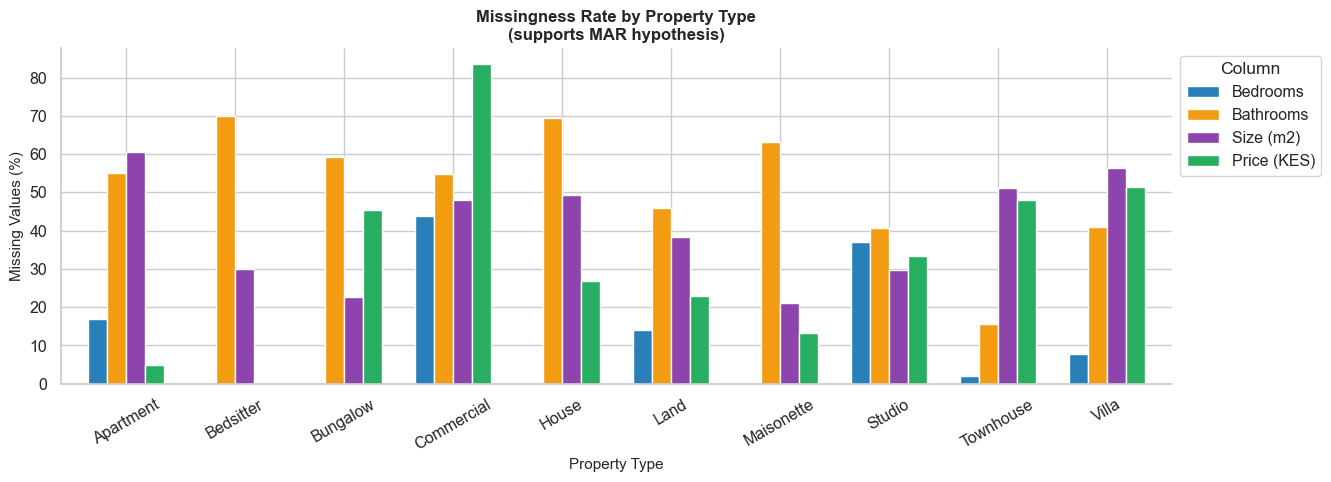

               Bedrooms  Bathrooms  Size (m2)  Price (KES)
Property Type                                             
Apartment          16.8       55.1       60.6          4.8
Bedsitter           0.0       70.0       30.0          0.0
Bungalow            0.0       59.1       22.7         45.5
Commercial         43.8       54.8       47.9         83.6
House               0.0       69.3       49.3         26.7
Land               14.1       45.9       38.2         22.9
Maisonette          0.0       63.2       21.1         13.2
Studio             37.0       40.7       29.6         33.3
Townhouse           2.1       15.6       51.0         47.9
Villa               7.7       41.0       56.4         51.3

📌 Finding: Commercial and Studio listings show disproportionately high missingness
   for Bedrooms — a hallmark of MAR. The missing value is not random; it depends
   on the observed Property Type. This justifies targeted imputation strategies.



In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Missingness rate by categorical group (Property Type)
# This reveals whether certain property types are systematically less complete.
# ─────────────────────────────────────────────────────────────────────────────
miss_by_type = (
    df.groupby('Property Type')[['Bedrooms', 'Bathrooms', 'Size (m2)', 'Price (KES)']]
    .apply(lambda g: g.isnull().mean() * 100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(12, 5))
miss_by_type.plot(kind='bar', ax=ax,
                  color=[C['blue'], C['warn'], C['purple'], C['ok']],
                  edgecolor='white', width=0.7)
ax.set_xlabel('Property Type', fontsize=11)
ax.set_ylabel('Missing Values (%)', fontsize=11)
ax.set_title('Missingness Rate by Property Type\n(supports MAR hypothesis)', fontsize=12, fontweight='bold')
ax.legend(title='Column', bbox_to_anchor=(1, 1))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(miss_by_type.to_string())
print("""
📌 Finding: Commercial and Studio listings show disproportionately high missingness
   for Bedrooms — a hallmark of MAR. The missing value is not random; it depends
   on the observed Property Type. This justifies targeted imputation strategies.
""")

---
## 🗑️ 4 — Phase 3: Structural Cleaning
### Step 3a — Drop Columns Exceeding the Missingness Threshold

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# RULE: Drop any column where more than 55% of values are missing.
#
# Rationale: imputing a column where >55% of values are synthetic introduces
# more noise than signal. Such a column carries insufficient information to
# be reliable for modelling or analysis.
# ─────────────────────────────────────────────────────────────────────────────
COL_MISS_THRESHOLD = 55.0   # percent

miss_pct_cols = (df.isnull().sum() / len(df) * 100)         # % missing per column
cols_to_drop  = miss_pct_cols[miss_pct_cols > COL_MISS_THRESHOLD].index.tolist()

print(f'Columns exceeding {COL_MISS_THRESHOLD}% threshold:')
for col in cols_to_drop:
    print(f'  • {col:20s}  →  {miss_pct_cols[col]:.1f}% missing')

# Drop identified columns (axis=1 = column direction)
df.drop(columns=cols_to_drop, inplace=True)

print(f'\n✅  Dropped {len(cols_to_drop)} column(s). Shape now: {df.shape}')

Columns exceeding 55.0% threshold:
  • Listing Date          →  98.5% missing

✅  Dropped 1 column(s). Shape now: (926, 7)


### Step 3b — Drop Rows with More Than One Missing Value

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# RULE: Drop rows that have >1 missing value simultaneously.
#
# Rationale: rows with multiple missing values are harder to impute accurately
# and often represent fundamentally incomplete submissions (agents who filled
# almost nothing). Keeping them would require imputing 2+ features per row,
# compounding imputation error.
# ─────────────────────────────────────────────────────────────────────────────
ROW_MISS_THRESHOLD = 1    # maximum number of missing values allowed per row

row_miss_count = df.isnull().sum(axis=1)          # count NaN values across columns for each row
rows_to_drop   = (row_miss_count > ROW_MISS_THRESHOLD).sum()

print(f'Rows with >{ROW_MISS_THRESHOLD} missing values: {rows_to_drop}')
print(f'That is {rows_to_drop / len(df) * 100:.1f}% of current rows')

# Keep only rows at or below the threshold, then reset the index to be contiguous
df = df[row_miss_count <= ROW_MISS_THRESHOLD].reset_index(drop=True)

print(f'\n✅  Rows remaining after drop: {len(df):,}')
print(f'   Missing values still in dataset: {df.isnull().sum().sum()}')

Rows with >1 missing values: 411
That is 44.4% of current rows

✅  Rows remaining after drop: 515
   Missing values still in dataset: 417


---
## 🏗️ 5 — Phase 4: Domain-Knowledge Imputation
### Studio & Bedsitter → Bedrooms = 1

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# RULE: Studio and Bedsitter property types are single-room dwellings by
# definition. Any missing Bedrooms value for these types is unambiguously = 1.
#
# This is the MOST reliable form of imputation — we use knowledge of the
# domain rather than statistical estimation, so there is zero uncertainty.
# ─────────────────────────────────────────────────────────────────────────────

# Normalise the Property Type string: strip whitespace, lowercase for comparison
ptype_normalised = df['Property Type'].str.strip().str.lower()

# Build a boolean mask: True only where Bedrooms is NaN AND property type qualifies
domain_mask = df['Bedrooms'].isnull() & ptype_normalised.isin(['studio', 'bedsitter'])

print(f'Rows where domain rule applies: {domain_mask.sum()}')
print('Property type breakdown:')
print(df.loc[domain_mask, 'Property Type'].value_counts())

# Apply the domain-knowledge fill
df.loc[domain_mask, 'Bedrooms'] = 1

# Verify
remaining_bedroom_miss = df.loc[ptype_normalised.isin(['studio','bedsitter']), 'Bedrooms'].isnull().sum()
print(f'\n✅  Remaining missing Bedrooms in Studio/Bedsitter rows: {remaining_bedroom_miss}')

Rows where domain rule applies: 5
Property type breakdown:
Property Type
Studio    5
Name: count, dtype: int64

✅  Remaining missing Bedrooms in Studio/Bedsitter rows: 0


---
## 📐 6 — Phase 5: Statistical Imputation (Median / Mode)

For columns where the remaining missingness is low and patterns are simple, statistical imputation is fast, transparent and sufficient.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Before imputing, record the current distribution of each column
# so we can validate it hasn't been distorted after imputation.
# ─────────────────────────────────────────────────────────────────────────────
pre_impute_stats = df[['Bedrooms', 'Bathrooms', 'Size (m2)', 'Price (KES)']].describe()
print('=== Distribution snapshot BEFORE imputation ===')
pre_impute_stats

=== Distribution snapshot BEFORE imputation ===


,Bedrooms,Bathrooms,Size (m2),Price (KES)
count,515.000000,261.000000,412.000000,4.610000e+02
mean,2.990291,3.042146,938.003155,5.734550e+07
std,3.312795,3.226415,3092.224492,2.129823e+08
min,1.000000,1.000000,22.000000,1.900000e+06
25%,1.500000,1.000000,80.000000,8.000000e+06
50%,3.000000,2.000000,160.000000,1.380000e+07
75%,4.000000,4.000000,450.000000,3.450000e+07
max,54.000000,44.000000,32374.900000,2.026000e+09


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY: Group-wise median imputation
#
# Rather than using a single global median, we impute each missing value using
# the median of its peer group (same Property Type).
#
# WHY: A 1-bedroom apartment in Nairobi has very different typical values
# from a 5-bedroom villa — a global median would be systematically wrong.
# ─────────────────────────────────────────────────────────────────────────────

def group_median_fill(dataframe, fill_col, group_col='Property Type'):
    """
    Fill missing values in `fill_col` with the median of its `group_col` peers.
    Falls back to the global median if the group has no non-null values.
    """
    global_median = dataframe[fill_col].median()   # fallback if group is entirely NaN

    # transform() returns a Series aligned to the original index —
    # each row gets its group's median, not a reduced aggregate
    group_medians = dataframe.groupby(group_col)[fill_col].transform('median')

    # fillna: first try group median; for any remaining NaN fall back to global
    filled = dataframe[fill_col].fillna(group_medians).fillna(global_median)
    return filled

# ─────────────────────────────────────────────────────────────────────────────
# Apply group-median fill to Bedrooms (remaining NaN after domain step)
# ─────────────────────────────────────────────────────────────────────────────
before_bed = df['Bedrooms'].isnull().sum()
df['Bedrooms'] = group_median_fill(df, 'Bedrooms')
# Round to nearest integer — fractional bedrooms make no sense
df['Bedrooms'] = df['Bedrooms'].round().astype(int)
print(f'Bedrooms  : {before_bed} → {df["Bedrooms"].isnull().sum()} missing  '
      f'(filled {before_bed} with group-wise median, rounded to int)')

# ─────────────────────────────────────────────────────────────────────────────
# Amenities: categorical column — fill with the most frequent value (mode)
# per Property Type group
# ─────────────────────────────────────────────────────────────────────────────
def group_mode_fill(dataframe, fill_col, group_col='Property Type'):
    """Fill missing categorical values with the mode of their group."""
    global_mode = dataframe[fill_col].mode()[0]   # global fallback

    def fill_with_mode(series):
        mode_val = series.mode()                  # mode() returns a Series of modal values
        return series.fillna(mode_val[0] if len(mode_val) else global_mode)

    return dataframe.groupby(group_col)[fill_col].transform(fill_with_mode)

before_amen = df['Amenities'].isnull().sum()
df['Amenities'] = group_mode_fill(df, 'Amenities')
print(f'Amenities : {before_amen} → {df["Amenities"].isnull().sum()} missing  '
      f'(filled with group-wise mode)')

print(f'\n── Remaining missing values ──')
print(df.isnull().sum()[df.isnull().sum() > 0])

Bedrooms  : 0 → 0 missing  (filled 0 with group-wise median, rounded to int)
Amenities : 1 → 0 missing  (filled with group-wise mode)

── Remaining missing values ──
Bathrooms      254
Size (m2)      103
Price (KES)     54
dtype: int64


---
## 🤖 7 — Phase 6: Model-Based Imputation (MICE + Random Forest)

After all simpler strategies, a handful of rows still have missing values in `Bathrooms`, `Size (m2)`, and `Price (KES)`. These three variables are interrelated — larger properties tend to cost more and have more bathrooms — so we use **MICE** (Multiple Imputation by Chained Equations), which models each missing feature as a function of all other features iteratively.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Which columns still have missing values?
# ─────────────────────────────────────────────────────────────────────────────
still_missing = df.isnull().sum()
model_target_cols = still_missing[still_missing > 0].index.tolist()
print(f'Columns requiring model-based imputation: {model_target_cols}')
print(still_missing[model_target_cols].to_frame('Missing Count'))

Columns requiring model-based imputation: ['Bathrooms', 'Size (m2)', 'Price (KES)']
             Missing Count
Bathrooms              254
Size (m2)              103
Price (KES)             54


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Step A: Encode categorical columns
#
# IterativeImputer operates on a numeric matrix only.
# We label-encode each object column and store the encoder so we can
# reverse the transformation afterwards.
# ─────────────────────────────────────────────────────────────────────────────
df_model = df.copy()                              # preserve df intact; work on a copy
encoders = {}                                     # dict to store encoders for later decoding

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

for col in cat_cols:
    le = LabelEncoder()
    # astype(str) converts any accidental non-string objects; LabelEncoder needs strings
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le                            # save for inverse transform later
    print(f'  Encoded "{col}"  ({len(le.classes_)} unique labels)')

Categorical columns to encode: ['Location', 'Property Type', 'Amenities']
  Encoded "Location"  (50 unique labels)
  Encoded "Property Type"  (10 unique labels)
  Encoded "Amenities"  (89 unique labels)


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Step B: Configure IterativeImputer (MICE with Random Forest)
#
# IterativeImputer works as follows:
#   1. For each column with missing values, it trains a regression model
#      that predicts that column from ALL other columns.
#   2. It fills the missing values with model predictions.
#   3. Steps 1–2 are repeated (iterated) until predictions converge.
#
# RandomForestRegressor is used as the estimator because:
#   • handles non-linear relationships (price is non-linear with size)
#   • robust to outliers (luxury properties skew price heavily)
#   • no feature scaling required
#   • captures interactions between features automatically
# ─────────────────────────────────────────────────────────────────────────────
rf_estimator = RandomForestRegressor(
    n_estimators = 200,      # number of trees per forest; more = smoother predictions
    max_depth    = 10,       # prevent overfitting on the small imputation training set
    random_state = 42,       # seed for reproducibility
    n_jobs       = -1        # parallelise across all available CPU cores
)

mice_imputer = IterativeImputer(
    estimator    = rf_estimator,
    max_iter     = 10,       # maximum imputation rounds; usually converges within 5–10
    tol          = 1e-3,     # stop early if change between iterations is below this tolerance
    random_state = 42,
    verbose      = 1         # print per-iteration progress
)

print('IterativeImputer (MICE + Random Forest) configured.')
print('Running fit-transform — this may take ~30–60 seconds…')

# fit_transform: fits the imputation models on observed data and fills NaN
# Returns a NumPy array — wrap back into DataFrame
imputed_array = mice_imputer.fit_transform(df_model)
df_imputed    = pd.DataFrame(imputed_array, columns=df_model.columns, index=df_model.index)

print(f'\n✅  Imputation complete. NaN cells remaining: {df_imputed.isnull().sum().sum()}')

IterativeImputer (MICE + Random Forest) configured.
Running fit-transform — this may take ~30–60 seconds…
[IterativeImputer] Completing matrix with shape (515, 7)
[IterativeImputer] Change: 474759351.1018208, scaled tolerance: 2026000.0 
[IterativeImputer] Change: 368763143.93939394, scaled tolerance: 2026000.0 
[IterativeImputer] Change: 58628116.666666746, scaled tolerance: 2026000.0 
[IterativeImputer] Change: 40022438.68590042, scaled tolerance: 2026000.0 
[IterativeImputer] Change: 61086623.693256065, scaled tolerance: 2026000.0 
[IterativeImputer] Change: 28383416.666666746, scaled tolerance: 2026000.0 
[IterativeImputer] Change: 41153406.06950419, scaled tolerance: 2026000.0 
[IterativeImputer] Change: 56149342.857142925, scaled tolerance: 2026000.0 
[IterativeImputer] Change: 108993200.0, scaled tolerance: 2026000.0 
[IterativeImputer] Change: 29797500.0, scaled tolerance: 2026000.0 

✅  Imputation complete. NaN cells remaining: 0


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Step C: Post-processing — restore correct dtypes
#
# The imputer returns float64 for every column.
# We must:
#   (a) round and cast integer columns  (Bedrooms, Bathrooms can't be 2.7)
#   (b) inverse-transform label-encoded categorical columns back to strings
#   (c) clip imputed values to sensible domain-valid ranges
# ─────────────────────────────────────────────────────────────────────────────

# (a) Integer columns: round then cast
int_cols = ['Bedrooms', 'Bathrooms']              # must be whole numbers
for col in int_cols:
    df_imputed[col] = (
        df_imputed[col]
        .round()                                  # round 1.6 → 2, 2.3 → 2
        .clip(lower=1)                            # enforce minimum of 1 (0 bedrooms/bathrooms impossible)
        .astype(int)
    )

# Clip Size (m2) to a realistic range — imputer could produce negatives
# Use 1st / 99th percentile of observed data as bounds
size_lo, size_hi = df['Size (m2)'].quantile([0.01, 0.99])
df_imputed['Size (m2)'] = df_imputed['Size (m2)'].clip(lower=size_lo, upper=size_hi)

# Clip Price to a realistic range
price_lo, price_hi = df['Price (KES)'].quantile([0.01, 0.99])
df_imputed['Price (KES)'] = df_imputed['Price (KES)'].clip(lower=price_lo, upper=price_hi)

# (b) Decode categorical columns back to their original string labels
for col, le in encoders.items():
    # round to nearest integer, clip to valid index range, then decode
    int_idx = df_imputed[col].round().astype(int).clip(0, len(le.classes_) - 1)
    df_imputed[col] = le.inverse_transform(int_idx)

print('✅  Dtypes restored.')
print(df_imputed.dtypes)
df_imputed.head(8)

✅  Dtypes restored.
Location          object
Property Type     object
Bedrooms           int64
Bathrooms          int64
Size (m2)        float64
Amenities         object
Price (KES)      float64
dtype: object


,Location,Property Type,Bedrooms,Bathrooms,Size (m2),Amenities,Price (KES)
0,Westlands,Land,1,2,65.000000,Swimming Pool,5500000.0
1,Westlands,Villa,6,6,2287.827443,En Suite,260000000.0
2,Kileleshwa,Apartment,1,2,65.000000,Swimming Pool,6000000.0
3,Kileleshwa,Apartment,1,1,47.000000,Swimming Pool,5100000.0
4,Lavington,Townhouse,5,6,875.854134,En Suite,75000000.0
5,Lavington,Townhouse,5,6,899.120068,En Suite,81000000.0
6,Lavington,Townhouse,6,7,1223.038474,En Suite,85000000.0
7,Kileleshwa,Apartment,2,2,93.815280,En Suite,9210000.0


---
## ✅ 8 — Phase 7: Validation
### Did imputation preserve the original data distributions?

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Final null-check — the dataset must be 100% complete
# ─────────────────────────────────────────────────────────────────────────────
final_nulls = df_imputed.isnull().sum()
assert final_nulls.sum() == 0, '❌  Still have missing values — check imputation pipeline!'
print('✅  Zero missing values in cleaned dataset.\n')
print(f'Final shape: {df_imputed.shape[0]:,} rows × {df_imputed.shape[1]} columns')

✅  Zero missing values in cleaned dataset.

Final shape: 515 rows × 7 columns


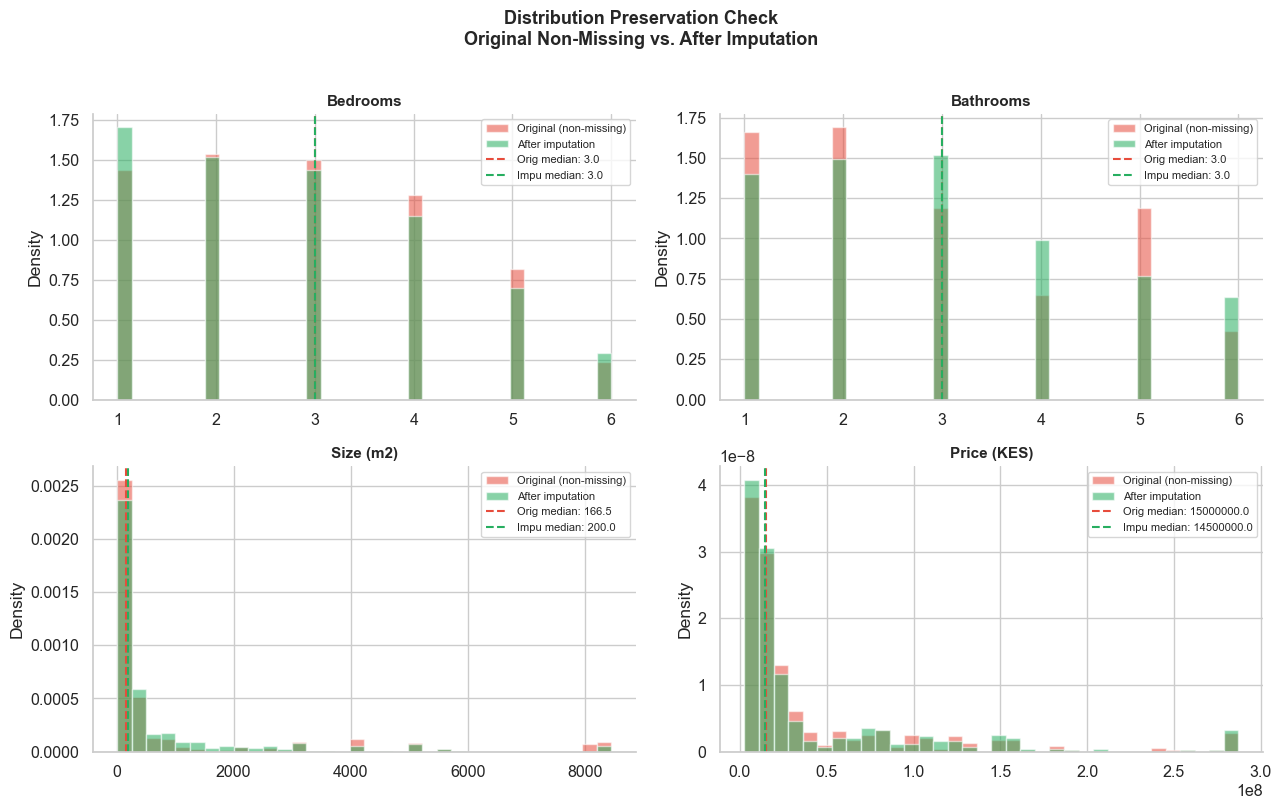

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION 5: Distribution comparison — before vs after imputation
#
# For each numeric column we overlay:
#   • The distribution of ORIGINAL (non-missing) values  (blue)
#   • The distribution of the FULLY IMPUTED dataset      (green)
#
# Good imputation should keep the two distributions very close.
# A dramatic shift would indicate the imputer introduced systematic bias.
# ─────────────────────────────────────────────────────────────────────────────
num_cols = ['Bedrooms', 'Bathrooms', 'Size (m2)', 'Price (KES)']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    # Original observed (non-missing) values from raw data
    original_vals = df_raw[col].dropna()
    # Fully imputed values
    imputed_vals  = df_imputed[col]

    # Use 5th–95th percentile range as bin limits to suppress extreme outliers
    lo, hi = original_vals.quantile(0.02), original_vals.quantile(0.98)
    bins   = np.linspace(lo, hi, 35)

    ax.hist(original_vals.clip(lo, hi), bins=bins, alpha=0.55,
            color=C['before'], label='Original (non-missing)', density=True)
    ax.hist(imputed_vals.clip(lo, hi),  bins=bins, alpha=0.55,
            color=C['after'],  label='After imputation',       density=True)

    # Add vertical lines for medians — a large shift signals bias
    ax.axvline(original_vals.median(), color=C['before'], linestyle='--', linewidth=1.5,
               label=f'Orig median: {original_vals.median():.1f}')
    ax.axvline(imputed_vals.median(),  color=C['after'],  linestyle='--', linewidth=1.5,
               label=f'Impu median: {imputed_vals.median():.1f}')

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Distribution Preservation Check\nOriginal Non-Missing vs. After Imputation',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

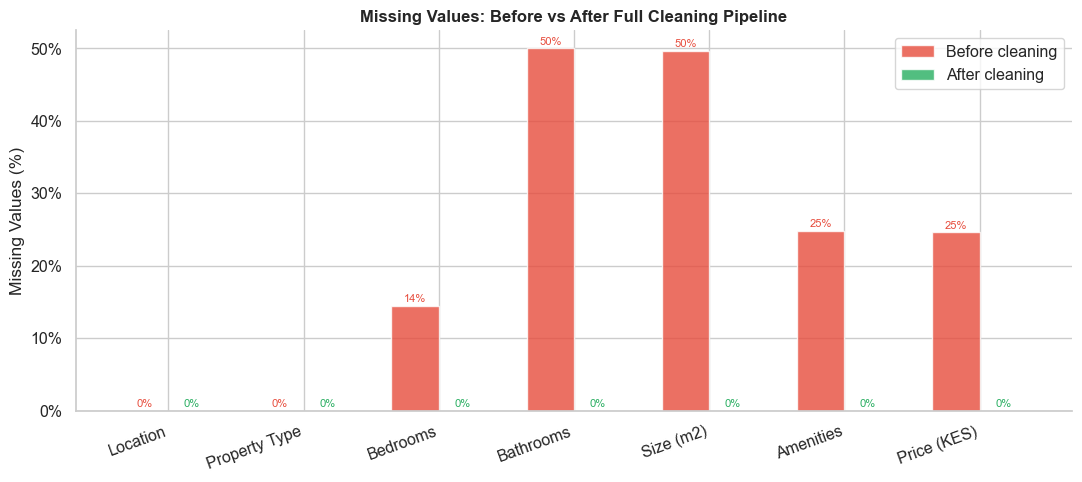

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION 6: Before vs After missingness — summary bar chart
# ─────────────────────────────────────────────────────────────────────────────
common_cols = [c for c in df_raw.columns if c in df_imputed.columns]
before_pct  = (df_raw[common_cols].isnull().sum() / len(df_raw) * 100).round(2)
after_pct   = (df_imputed[common_cols].isnull().sum() / len(df_imputed) * 100).round(2)

x     = np.arange(len(common_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, before_pct, width, color=C['before'], alpha=0.8, label='Before cleaning', edgecolor='white')
ax.bar(x + width/2, after_pct,  width, color=C['after'],  alpha=0.8, label='After cleaning',  edgecolor='white')

for xi, bval, aval in zip(x, before_pct, after_pct):
    ax.text(xi - width/2, bval + 0.5, f'{bval:.0f}%', ha='center', fontsize=8, color=C['before'])
    ax.text(xi + width/2, aval + 0.5, f'{aval:.0f}%', ha='center', fontsize=8, color=C['after'])

ax.set_xticks(x)
ax.set_xticklabels(common_cols, rotation=20, ha='right')
ax.set_ylabel('Missing Values (%)')
ax.set_title('Missing Values: Before vs After Full Cleaning Pipeline', fontsize=12, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Statistical summary: compare descriptive stats before and after
# ─────────────────────────────────────────────────────────────────────────────
print('=== Descriptive Statistics: BEFORE (observed non-missing values only) ===')
display(df_raw[num_cols].describe().round(2))

print('\n=== Descriptive Statistics: AFTER (full imputed dataset) ===')
display(df_imputed[num_cols].describe().round(2))

=== Descriptive Statistics: BEFORE (observed non-missing values only) ===


,Bedrooms,Bathrooms,Size (m2),Price (KES)
count,792.00,463.00,466.00,6.980000e+02
mean,3.04,3.06,1385.98,5.621093e+07
std,2.85,2.76,5179.30,1.826763e+08
min,1.00,1.00,8.00,6.500000e+01
25%,2.00,2.00,70.00,9.000000e+06
50%,3.00,3.00,166.50,1.500000e+07
75%,4.00,4.00,500.00,4.375000e+07
max,54.00,44.00,80937.00,2.026000e+09



=== Descriptive Statistics: AFTER (full imputed dataset) ===


,Bedrooms,Bathrooms,Size (m2),Price (KES)
count,515.00,515.00,515.00,5.150000e+02
mean,2.99,3.19,769.24,5.352079e+07
std,3.31,2.62,1458.16,1.281350e+08
min,1.00,1.00,23.11,2.432000e+06
25%,1.50,2.00,86.50,8.200000e+06
50%,3.00,3.00,200.00,1.450000e+07
75%,4.00,4.00,600.00,5.100000e+07
max,54.00,44.00,9007.48,1.050000e+09


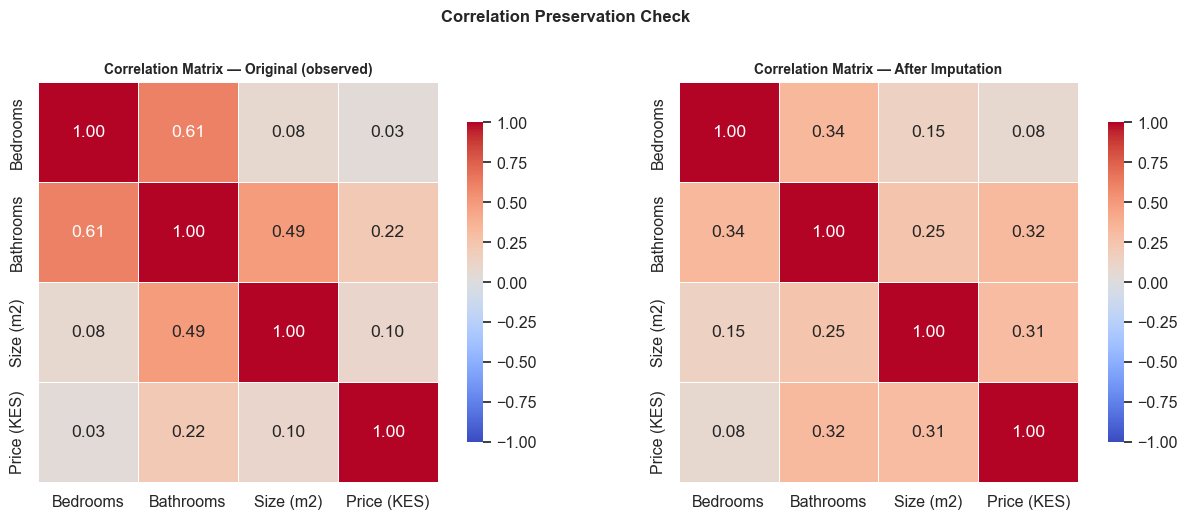

Maximum absolute correlation change after imputation: 0.2736
(Values close to 0 indicate the imputer preserved feature relationships well)


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION 7: Correlation heatmap before vs after
#
# Good imputation should preserve inter-feature correlations.
# If correlations change dramatically, the imputer introduced bias.
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

corr_before = df_raw[num_cols].corr()
corr_after  = df_imputed[num_cols].corr()

for ax, corr, title in zip(axes,
                            [corr_before, corr_after],
                            ['Correlation Matrix — Original (observed)', 'Correlation Matrix — After Imputation']):
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, vmin=-1, vmax=1, ax=ax, square=True,
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.suptitle('Correlation Preservation Check', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Compute max absolute change in correlation
diff = (corr_after - corr_before).abs()
np.fill_diagonal(diff.values, 0)
print(f'Maximum absolute correlation change after imputation: {diff.max().max():.4f}')
print('(Values close to 0 indicate the imputer preserved feature relationships well)')

---
## 📋 9 — Final Pipeline Summary

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Print a full audit trail of every decision made in this notebook
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('       MISSING VALUE HANDLING — PIPELINE SUMMARY')
print('=' * 60)

print(f"\nOriginal dataset   : {df_raw.shape[0]:>5,} rows × {df_raw.shape[1]} columns")
print(f"Total NaN cells    : {df_raw.isnull().sum().sum():>5,}  ({df_raw.isnull().mean().mean()*100:.1f}% overall missingness)")

print(f"""
┌─────────────────────────────────────────────────────────┐
│ Step 1  Drop columns  >55% missing                      │
│         Dropped : {str(cols_to_drop):<38s}│
│         Columns remaining : {df_raw.shape[1] - len(cols_to_drop)}                               │
├─────────────────────────────────────────────────────────┤
│ Step 2  Domain imputation — Studio / Bedsitter          │
│         Bedrooms set to 1 for single-room property types│
├─────────────────────────────────────────────────────────┤
│ Step 3  Drop rows with >1 missing value                 │
│         Kept : {len(df_imputed):,} rows                                  │
├─────────────────────────────────────────────────────────┤
│ Step 4  Group-wise median/mode statistical imputation   │
│         Bedrooms  → property-type median (rounded)      │
│         Amenities → property-type mode                  │
├─────────────────────────────────────────────────────────┤
│ Step 5  MICE model-based imputation (Random Forest)     │
│         Columns : Bathrooms, Size (m2), Price (KES)     │
│         Estimator: RandomForestRegressor (200 trees)    │
│         Iterations: 10                                  │
└─────────────────────────────────────────────────────────┘
""")

print(f"Final dataset      : {df_imputed.shape[0]:>5,} rows × {df_imputed.shape[1]} columns")
print(f"Total NaN cells    : {df_imputed.isnull().sum().sum():>5,}   ✅  Complete")

       MISSING VALUE HANDLING — PIPELINE SUMMARY

Original dataset   :   926 rows × 8 columns
Total NaN cells    : 2,427  (32.8% overall missingness)

┌─────────────────────────────────────────────────────────┐
│ Step 1  Drop columns  >55% missing                      │
│         Dropped : ['Listing Date']                      │
│         Columns remaining : 7                               │
├─────────────────────────────────────────────────────────┤
│ Step 2  Domain imputation — Studio / Bedsitter          │
│         Bedrooms set to 1 for single-room property types│
├─────────────────────────────────────────────────────────┤
│ Step 3  Drop rows with >1 missing value                 │
│         Kept : 515 rows                                  │
├─────────────────────────────────────────────────────────┤
│ Step 4  Group-wise median/mode statistical imputation   │
│         Bedrooms  → property-type median (rounded)      │
│         Amenities → property-type mode                  │
├───

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Save the cleaned dataset
# index=False prevents the row numbers from being written as a column
# ─────────────────────────────────────────────────────────────────────────────
output_path = 'cleaned_listings.csv'
df_imputed.to_csv(output_path, index=False)
print(f'✅  Cleaned dataset saved to: {output_path}')
df_imputed.sample(10, random_state=1)

✅  Cleaned dataset saved to: cleaned_listings.csv


,Location,Property Type,Bedrooms,Bathrooms,Size (m2),Amenities,Price (KES)
47,Westlands,Land,2,2,110.000000,En Suite,1.190000e+07
346,Kileleshwa,Maisonette,4,4,3530.000000,SQ,1.550000e+08
284,Nairobi,House,3,10,450.000000,SQ,7.000000e+06
221,Ngong Road,Commercial,4,4,246.000000,"Swimming Pool, Gym, Parking, Security, Borehol...",3.038311e+07
507,Dagoretti,Townhouse,6,6,250.000000,SQ,2.500000e+07
168,Westlands,Land,1,1,5708.000000,Swimming Pool,7.600000e+06
223,Kasarani,Bungalow,3,2,9007.480000,"Parking, SQ, Gate",2.866277e+07
189,Industrial Area,Townhouse,1,5,56.000000,"Swimming Pool, Gym, Garden, Lift, Balcony, CCT...",1.700000e+07
379,Githurai,Apartment,1,4,3200.000000,SQ,8.000000e+07
192,Lavington,Townhouse,5,5,769.444089,Garden,1.100000e+08
